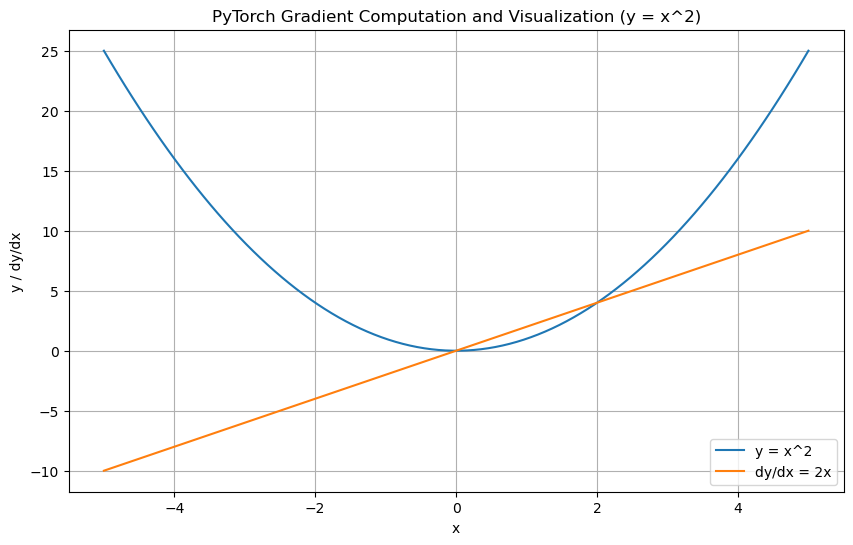

In [1]:
# Use autograd in PyTorch to compute the derivative of a function automatically.
# We illustrate this by d f/dx = 2x, f = x^2. And make a plot.
import numpy
import torch
import matplotlib.pyplot as plt

# 1. Define a tensor with requires_grad=True
# 100 data points x from -5 to 5.
x = torch.linspace(-5, 5, 100, requires_grad=True)

# 2. Define the function, y = f(x) = x^2
y = x**2

# 3. Perform a backward pass to compute gradients
# Since y is a tensor of multiple values (from x), and we want the gradient 
# of each y_i with respect to x_i, we need to sum y first to get a scalar value 
# for the backward pass, or iterate and call backward on each y_i
# For simplicity, we'll sum y and compute the gradient of the sum with respect to x
# The derivative of x^2 is 2x.  Note, we don't compute dy/dx explicitly in code.
y_sum = y.sum()
y_sum.backward()

# 4. Access the gradient
g = x.grad

# 5. Plot the function and its gradient.  Need .detach() and then 
# convert to numpy type.  g is a normal tensor, so no need to .detach().
plt.figure(figsize=(10, 6))

plt.plot(x.detach().numpy(), y.detach().numpy(), label='y = x^2')
plt.plot(x.detach().numpy(), g.numpy(), label='dy/dx = 2x')

plt.xlabel('x')
plt.ylabel('y / dy/dx')
plt.title('PyTorch Gradient Computation and Visualization (y = x^2)')
plt.legend()
plt.grid(True)
plt.show()